In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
df=pd.read_csv("nyc_tlc_cleaned.csv")

In [3]:
tar=df["total_amount"]

In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,PU_Borough,DO_Borough,trip_duration,pickup_hour,pickup_weekday,pickup_month,pickup_day,is_weekend
0,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,0,1,13.0,0.0,...,0.3,16.56,Manhattan,Manhattan,844.0,8,5,3,25,1
1,1,2017-04-11 14:53:00,2017-04-11 15:19:00,1,1.80,1,0,1,16.0,0.0,...,0.3,20.80,Manhattan,Manhattan,1560.0,14,1,4,11,0
2,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,0,1,6.5,0.0,...,0.3,8.75,Manhattan,Manhattan,432.0,7,4,12,15,0
3,2,2017-05-07 13:17:00,2017-05-07 13:48:00,1,3.70,1,0,1,20.5,0.0,...,0.3,27.69,Brooklyn,Brooklyn,1860.0,13,6,5,7,1
4,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,0,2,16.5,0.5,...,0.3,17.80,Manhattan,Brooklyn,1003.0,23,5,4,15,1


In [5]:
feat=df.drop(columns=['total_amount',
    'fare_amount','extra','tip_amount','tolls_amount','improvement_surcharge','tpep_pickup_datetime','tpep_dropoff_datetime'])

In [6]:
df["PU_Borough"].unique()

array(['Manhattan', 'Brooklyn', 'Queens', 'Unknown', 'EWR', 'Bronx',
       'Staten Island'], dtype=object)

In [7]:
df["DO_Borough"].unique()

array(['Manhattan', 'Brooklyn', 'Bronx', 'Queens', 'Unknown',
       'Staten Island', 'EWR'], dtype=object)

In [8]:
#doing one hot encoding on each categorical data
from sklearn.preprocessing import OneHotEncoder
#one=OneHotEncoder(sparse=False,handle_unknown='ignore')
pu_encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
do_encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
flag_encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

In [9]:
do_df = pd.DataFrame(do_encoder.fit_transform(df[['DO_Borough']]),columns=do_encoder.get_feature_names_out(['DO_Borough']))


In [10]:
do_df.head()


,DO_Borough_Bronx,DO_Borough_Brooklyn,DO_Borough_EWR,DO_Borough_Manhattan,DO_Borough_Queens,DO_Borough_Staten Island,DO_Borough_Unknown
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [11]:
pu_df=pd.DataFrame(pu_encoder.fit_transform(df[['PU_Borough']]),columns=pu_encoder.get_feature_names_out(['PU_Borough']))

In [12]:
pu_df.head()

,PU_Borough_Bronx,PU_Borough_Brooklyn,PU_Borough_EWR,PU_Borough_Manhattan,PU_Borough_Queens,PU_Borough_Staten Island,PU_Borough_Unknown
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [13]:
flag_df=pd.DataFrame(flag_encoder.fit_transform(df[['store_and_fwd_flag']]),columns=flag_encoder.get_feature_names_out(['store_and_fwd_flag']))

In [14]:
flag_df.head()

,store_and_fwd_flag_0,store_and_fwd_flag_1
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0


In [15]:
df_encoded=pd.concat([df.drop(columns=['PU_Borough','DO_Borough','store_and_fwd_flag']),pu_df,do_df,flag_df],axis=1)

In [16]:
df_encoded.shape

(22481, 36)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x=df_encoded.drop(columns=['total_amount',
    'fare_amount','extra','tip_amount','tolls_amount','improvement_surcharge','tpep_pickup_datetime','tpep_dropoff_datetime'])

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,tar,test_size=0.2,random_state=72)

In [20]:
x_train

,VendorID,passenger_count,trip_distance,RatecodeID,payment_type,mta_tax,trip_duration,pickup_hour,pickup_weekday,pickup_month,...,PU_Borough_Unknown,DO_Borough_Bronx,DO_Borough_Brooklyn,DO_Borough_EWR,DO_Borough_Manhattan,DO_Borough_Queens,DO_Borough_Staten Island,DO_Borough_Unknown,store_and_fwd_flag_0,store_and_fwd_flag_1
6496,2,1,0.66,1,1,0.5,300.0,7,1,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
343,2,5,6.25,1,1,0.5,1920.0,8,1,12,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
12555,1,1,6.25,1,1,0.5,2138.0,16,0,12,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8408,1,1,0.70,1,2,0.5,267.0,18,3,5,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4246,1,1,1.60,1,2,0.5,978.0,15,2,10,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2885,2,1,1.91,1,1,0.5,1189.0,16,1,9,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
20325,2,1,1.19,1,1,0.5,660.0,14,4,10,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7242,2,1,0.80,1,1,0.5,240.0,0,6,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5166,2,1,0.50,1,2,0.5,180.0,21,4,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [21]:
y_train

6496      6.960
343      31.375
12555    31.375
8408      6.800
4246     12.800
          ...  
2885     15.800
20325    10.300
7242      8.160
5166      5.300
12760     7.300
Name: total_amount, Length: 17984, dtype: float64

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
ss=StandardScaler()

In [24]:
x_train_new=ss.fit_transform(x_train)

In [25]:
x_test_new=ss.transform(x_test)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model=LinearRegression()

In [28]:
model.fit(x_train_new,y_train)

LinearRegression()

In [29]:
test_pred=model.predict(x_test_new)
train_pred=model.predict(x_train_new)


In [30]:
from sklearn.metrics import r2_score

In [31]:
r2=r2_score(y_test,test_pred)

In [32]:
r2

0.9484234085492257

**R2 SCORE IN MULTI LINEAR REGRESSION IS 0.948455**

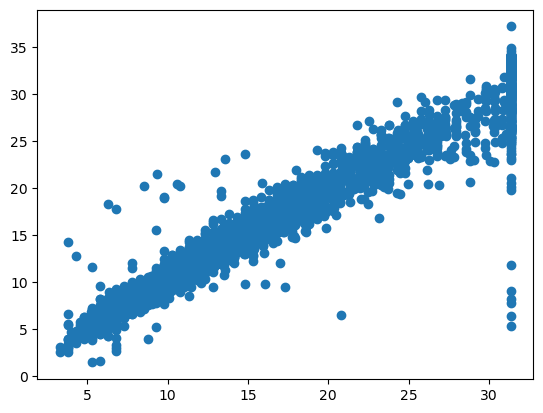

In [33]:
import matplotlib.pyplot as plt
plt.scatter(y_test,test_pred)

In [34]:
x_test_new

array([[ 0.88961424, -0.49732001, -0.49595214, ..., -0.11921239,
         0.06557434, -0.06557434],
       [ 0.88961424, -0.49732001,  0.03291149, ...,  8.38838956,
         0.06557434, -0.06557434],
       [ 0.88961424, -0.49732001,  0.0710769 , ..., -0.11921239,
         0.06557434, -0.06557434],
       ...,
       [-1.12408273,  1.84501166,  2.13200941, ..., -0.11921239,
         0.06557434, -0.06557434],
       [ 0.88961424, -0.49732001,  0.7526022 , ..., -0.11921239,
         0.06557434, -0.06557434],
       [ 0.88961424,  0.28345721, -0.95393715, ..., -0.11921239,
         0.06557434, -0.06557434]])

In [35]:
y_train

6496      6.960
343      31.375
12555    31.375
8408      6.800
4246     12.800
          ...  
2885     15.800
20325    10.300
7242      8.160
5166      5.300
12760     7.300
Name: total_amount, Length: 17984, dtype: float64

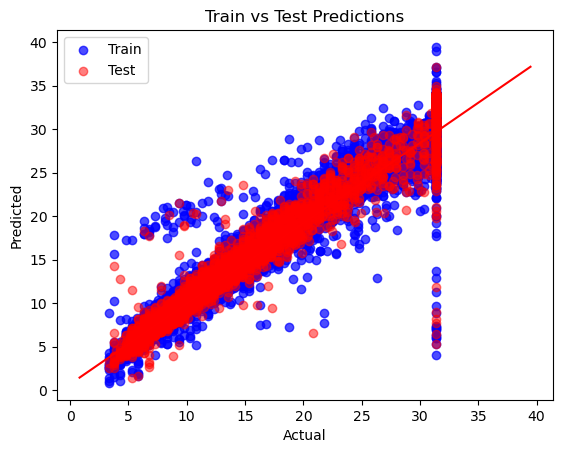

In [36]:
plt.scatter(y_train,train_pred, color='blue', alpha=0.7, label='Train')
plt.scatter(y_test, test_pred, color='red',alpha=0.5, label='Test')

plt.plot([train_pred.min(), train_pred.max()],[test_pred.min(), test_pred.max()],color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Train vs Test Predictions")
plt.legend()

plt.show()

In [37]:
import pandas as pd

In [38]:
x=df['trip_distance'].to_frame('distance')
y=tar

In [39]:
x.head()

,distance
0,3.34
1,1.80
2,1.00
3,3.70
4,4.37


In [40]:
y.head()

0    16.56
1    20.80
2     8.75
3    27.69
4    17.80
Name: total_amount, dtype: float64

In [41]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22481 entries, 0 to 22480
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   distance  22481 non-null  float64
dtypes: float64(1)
memory usage: 175.8 KB


In [42]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [44]:
x_train_new=ss.fit_transform(x_train)
x_test_new=ss.transform(x_test)

In [45]:
x_train_new

array([[-0.45662344],
       [-0.64213281],
       [ 2.13505156],
       ...,
       [-0.62030817],
       [-0.94767765],
       [-0.34750028]])

In [46]:
x_test_new

array([[-1.05680081],
       [ 1.28934708],
       [-1.00223923],
       ...,
       [-0.46753575],
       [-1.07316928],
       [-0.64758896]])

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_new, y_train)

LinearRegression()

In [48]:
y_test_pred = model.predict(x_test_new)
y_train_pred = model.predict(x_train_new)

In [49]:
r2 = r2_score(y_test, y_test_pred)
r2

0.8663067234837979

**R2 SCORE IN LINEAR REGRESSION IS 0.866306**

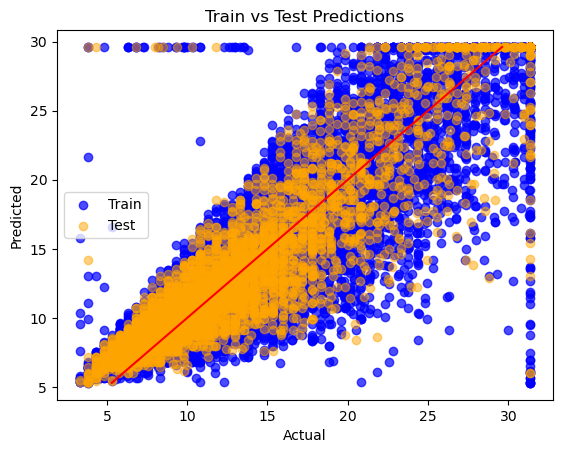

In [50]:
plt.scatter(y_train,y_train_pred, color='blue', alpha=0.7, label='Train')
plt.scatter(y_test, y_test_pred, color='orange',alpha=0.5, label='Test')

plt.plot([y_train_pred.min(), y_train_pred.max()],[y_test_pred.min(), y_test_pred.max()],color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Train vs Test Predictions")
plt.legend()

plt.show()

In [51]:
from sklearn.preprocessing import PolynomialFeatures

In [52]:
poly = PolynomialFeatures(degree=2)
x_train_new2 = poly.fit_transform(x_train)
x_test_new2 = poly.transform(x_test)

In [53]:
model = LinearRegression()
model.fit(x_train_new2, y_train)

LinearRegression()

In [54]:
y_pred=model.predict(x_test_new2)

In [55]:
r2=r2_score(y_test,y_pred)
r2

0.8664285164120246

**R2 SCORE IN POLYNOMIAL REGRESSION OF DEGREE 2 IS 0.86642**

In [56]:
polyy = PolynomialFeatures(degree=3)
x_train_new3 = polyy.fit_transform(x_train)
x_test_new3 = polyy.transform(x_test)
model = LinearRegression()
model.fit(x_train_new3, y_train)
y_predd=model.predict(x_test_new3)
r2=r2_score(y_test,y_predd)
r2

0.8688684388700323

**R2 SCORE IN POLYNOMIAL REGRESSION OF DEGREE 3 IS 0.868868**

In [57]:
poly6 = PolynomialFeatures(degree=6)
x_train_new6 = poly6.fit_transform(x_train)
x_test_new6 = poly6.transform(x_test)
model = LinearRegression()
model.fit(x_train_new6, y_train)
y_pred6=model.predict(x_test_new6)
r2=r2_score(y_test,y_pred6)
r2

0.8700605629940477

**R2 SCORE IN POLYNOMIAL REGRESSION OF DEGREE 6 IS 0.87006**

In [58]:
y_test_pred = model.predict(x_test_new6)
y_train_pred = model.predict(x_train_new6)

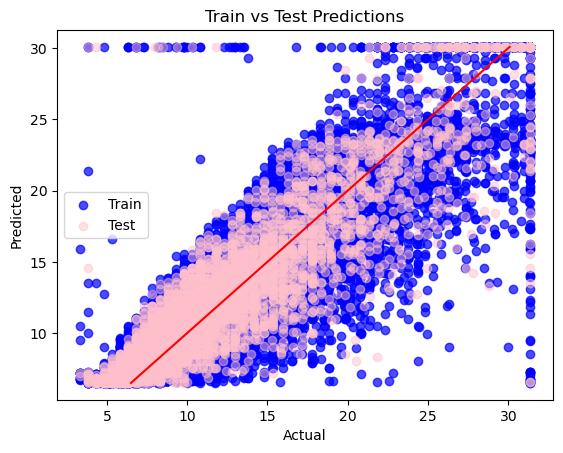

In [59]:
plt.scatter(y_train,y_train_pred, color='blue', alpha=0.7, label='Train')
plt.scatter(y_test, y_test_pred, color='pink',alpha=0.5, label='Test')

plt.plot([y_train_pred.min(), y_train_pred.max()],[y_test_pred.min(), y_test_pred.max()],color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Train vs Test Predictions")
plt.legend()

plt.show()

***CONCLUSION***\
***TO PREDICT TOTAL_AMOUNT***\
***ACCURACY METRIC : R2 SCORE***\
***WE WOULD CONSIDER MULTI LINEAR REGRESSION(HIGHEST R2 SCORE OF 0.9484550)***\
***PREDICTION IS BASED ON FEATURES LIKE PASSENGER_COUNT, TRIP_DISTANCE, ETC***